# 1.模型数学

 本节核心:输出从"一个数"变成"一个概率分布"

线性回归输出一个标量 ŷ 是一个连续的数值;分类问题输出的是每个类别的概率。以 Fashion-MNIST 为例:
(1)输入:28×28 = 784 个像素特征;
(2)输出:10 类(上衣、裤子、鞋……)的概率分布;
(3)我们希望:正确类别的概率尽量接近 1,其余接近 0

模型结构(一层线性 + softmax):
$o_i = \mathbf{x} \cdot \mathbf{w}_i + b_i \quad (i = 1,\dots,10)$
其中 $\mathbf{o}$ 叫 logits(未归一化的得分)。注意权重是个矩阵:
(1)W 形状 [[10, 784]](每个类别一根权重向量);
(2)b 形状 [10];
(3)一次处理一批:$\mathbf{O} = \mathbf{X}\mathbf{W}^T + \mathbf{b}$(X 形状 [256, 784] → 输出 [256, 10])

Softmax:把 logits 变成概率
$\hat{y}_i = \frac{e^{o_i}}{\sum_{j=1}^{10} e^{o_j}}$
两个性质:①每个 $\hat{y}_i \in (0,1)$;②$\sum_i \hat{y}_i = 1$。这样就敢当概率用了。

交叉熵损失（Cross Entropy Loss）:只惩罚"正确答案上的概率太小"
$l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{i=1}^{10} y_i \log \hat{y}_i = -\log \hat{y}_{y}$
因为真实标签 $\mathbf{y}$ 是 one-hot(只有正确类那位是 1),所以求和塌缩成一句:损失 = 正确类概率的对数的相反数。 正确类概率越接近 1,损失越接近 0。

为什么不用 MSE 做分类?
(1)MSE 假设误差是高斯分布,分类是伯努利/多项分布,用错损失=用错假设;
(2)MSE + softmax 会有梯度饱和:softmax 输出接近 0 或 1 时,曲线变平,梯度消失,训练慢;
(3)交叉熵的梯度是线性的、不饱和,训练快。

最漂亮的一个式子(交叉熵的梯度):
$\frac{\partial l}{\partial o_j} = \hat{y}_j - y_j$
预测减真实——跟线性回归里"残差"的优雅程度一样。这也是"softmax + 交叉熵"天生是一对的原因:loss 对 logits 的导数简单到不用经过 softmax 的分母。写代码时记住它,能解释后面所有数值技巧。


# 2.数值稳定性的坑

Softmax 里有 exp()，如果 logits 很大，exp 之后会溢出（变成 inf）
两个解法,都要理解:

解法一:softmax 平移不变性。 分子分母同乘 $e^{-m}$(m = 该行最大值)值不变:
$\hat{y}_i = \frac{e^{o_i - m}}{\sum_j e^{o_j - m}}$
先 o - o.max(dim, keepdim) 再 exp,永不溢出。

解法二(更妙):把 softmax 和 log 合并成 log_softmax。 因为损失里是 $\log \hat{y}_y$,展开:
$\log \hat{y}_y = o_y - \log\sum_j e^{o_j}$
这叫 LogSumExp 技巧。指数和的对数,精度高且数值稳。PyTorch 的 nn.CrossEntropyLoss 内部干的就是这件事:log_softmax + nll_loss,两步合成一步。 你从零实现时,F.log_softmax 可以借(它只是数值安全的 log softmax,不算"作弊"),但交叉熵的求和、索引、取平均必须自己写。

# 3.导入 + 数据

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256  # 单次迭代一次性读取 256 张图片样本，一批 (batch) 的数据规模
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
'''
d2l.load_data_fashion_mnist()：d2l 库封装好的 Fashion‑MNIST 数据集加载函数
train_iter：训练集迭代器，循环时每次返回 (X,y) 一批训练图片 + 标签
test_iter：测试集迭代器，用于模型验证、测试，不参与参数更新

每张图会被自动展平成 784 维向量,Fashion-MNIST 共 10 类。
'''

# 4.生成合成数据集

features: tensor([0.8204, 0.7295]) 
label: tensor([3.3592])


'\n为什么取 features[:, 1](第 2 个特征)?\nfeatures 的形状是 (1000, 2)  —— 1000 个样本,每个样本 2 个特征\nfeatures[:, 1]  =  所有行的第 2 列(0 起数,索引 1)\n\n真正的权重是 true_w = [2, -3.4]:\n第 1 个特征 × 权重 2(正相关)\n第 2 个特征 × 权重 -3.4(负相关)\n书里故意取第 2 个特征来画,是因为这样你能看到一条向下倾斜的直线,更直观地说明"学到的关系是负的"。你取 features[:, 0] 画,则是一条向上倾斜的直线。\n\n为什么 .detach()?\n.detach() = "把数据从求导体系里摘出来,只留数值"。\ndetach() 是"从计算图里脱离"的意思。\n有些张量是被要求记录梯度的(requires_grad=True),它们在 PyTorch 里叫"需要求导的张量";\n而 .numpy() 不允许对这类张量直接转换,会报错。\nfeatures 这个例子其实是 torch.normal 直接生成的、没有梯度,不 detach 也能转。但 d2l 里统一写成 .detach() 是安全惯例——不管这个张量背后有没有计算图,先摘出来再说,保证在任何场景都能转。\n\n为什么 .numpy()?\n因为 matplotlib 不认 PyTorch 张量,它只认 NumPy 数组(Python 列表也行)。所以先 .numpy() 把张量翻译成 numpy 数组再喂给 scatter。\n补充:features 在 CPU 上,所以直接 .numpy() 就行。如果张量在 GPU(cuda)上,得先 .cpu() 再 .numpy()。\n\n为什么最后有个 1\n这是 scatter(x, y, s) 的第三个位置参数,s = 每个点的大小(面积)。设成 1 是因为有 1000 个点:\n用默认大小(约 20)会糊成一片黑;\n设成 1 每个点只有 1 像素,1000 个点铺开就是一条清晰的"细线"。\n'

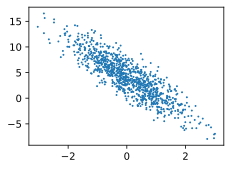

In [13]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    # 正态分布采样，从均值为 0、标准差为 1 的正态分布（标准正态分布）里随机采样
    X = torch.normal(0, 1, (num_examples, len(w)))  # 特征
    # 矩阵乘法实现线性回归
    y = torch.matmul(X, w) + b                       # 标签 = Xw + b,torch.matmul() —— 矩阵乘法
    # 加入均值为 0、标准差为 0.01 呈正态分布的噪声
    y += torch.normal(0, 0.01, y.shape)             # 加噪声
    return X, y.reshape((-1, 1))         # -1 是 PyTorch 的语法糖：自动推断这个维度该是多少（这里就是 1000）

true_w = torch.tensor([2, -3.4])   # torch.tensor() —— 从数据创建张量
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('features:', features[0], '\nlabel:', labels[0])

'''
为什么用正态分布？因为线性回归的假设就是噪声服从正态分布，特征也常假设为正态分布
torch.normal() —— 正态分布采样

y.reshape((-1, 1)) —— 为什么要变成列向量？
后面算损失时，y_hat 是 (batch_size, 1)，形状要对齐才能广播运算

torch.normal(0, 1, ...) 生成 1000 个标准正态分布的特征样本 X;
用真实权重 true_w = [2, -3.4]、偏差 true_b = 4.2 算出 y = Xw + b,再加一点方差 0.01 的噪声——这就是我们要"学回来"的隐藏答案。
'''

d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)
# d2l.plt.scatter() —— 散点图
'''
为什么取 features[:, 1](第 2 个特征)?
features 的形状是 (1000, 2)  —— 1000 个样本,每个样本 2 个特征
features[:, 1]  =  所有行的第 2 列(0 起数,索引 1)

真正的权重是 true_w = [2, -3.4]:
第 1 个特征 × 权重 2(正相关)
第 2 个特征 × 权重 -3.4(负相关)
书里故意取第 2 个特征来画,是因为这样你能看到一条向下倾斜的直线,更直观地说明"学到的关系是负的"。你取 features[:, 0] 画,则是一条向上倾斜的直线。

为什么 .detach()?
.detach() = "把数据从求导体系里摘出来,只留数值"。
detach() 是"从计算图里脱离"的意思。
有些张量是被要求记录梯度的(requires_grad=True),它们在 PyTorch 里叫"需要求导的张量";
而 .numpy() 不允许对这类张量直接转换,会报错。
features 这个例子其实是 torch.normal 直接生成的、没有梯度,不 detach 也能转。但 d2l 里统一写成 .detach() 是安全惯例——不管这个张量背后有没有计算图,先摘出来再说,保证在任何场景都能转。

为什么 .numpy()?
因为 matplotlib 不认 PyTorch 张量,它只认 NumPy 数组(Python 列表也行)。所以先 .numpy() 把张量翻译成 numpy 数组再喂给 scatter。
补充:features 在 CPU 上,所以直接 .numpy() 就行。如果张量在 GPU(cuda)上,得先 .cpu() 再 .numpy()。

为什么最后有个 1
这是 scatter(x, y, s) 的第三个位置参数,s = 每个点的大小(面积)。设成 1 是因为有 1000 个点:
用默认大小(约 20)会糊成一片黑;
设成 1 每个点只有 1 像素,1000 个点铺开就是一条清晰的"细线"。
'''

# 5.初始化模型参数 + 三件套

In [14]:
# 1. 初始化模型参数（参数）
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)    # torch.normal() —— 正态分布采样
b = torch.zeros(1, requires_grad=True)   # torch.zeros() —— 创建全零张量

# 2. 定义模型（模型）
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

# 3. 定义损失函数（损失）
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

# 4. 定义优化算法（优化器）
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():     # torch.no_grad() —— 关闭梯度计算上下文
        for param in params:
            param -= lr * param.grad / batch_size   # .grad —— 梯度属性
            param.grad.zero_()   # .zero_() —— 原地清零
'''
1. 初始化参数
w 是 (2,1) 的向量(两个特征 → 两个权重),从均值为 0、标准差 0.01 的正态分布里随机抽。随机是为了打破对称(如果都初始成 0,对神经网络是灾难,线性回归倒还能学,但这是好习惯);
b 是标量(1 维),初始成 0 就行——偏差本来就可以从 0 起步;
requires_grad=True 告诉 PyTorch:这两个张量要记梯度,是 PyTorch 自动求导的开关,后面 loss.backward() 才能算出 ∂loss/∂w、∂loss/∂b。

2.linreg 就是 X @ w + b
一个矩阵乘法加广播,没别的。这就是线性回归模型本身。

3.损失函数为什么要 / 2
这是均方误差(MSE),但多了个 /2;
原因:平方函数求导会带出个 2,除以 2 之后导数正好是 (y_hat - y),式子干净好算。数学上最优解不变,只是求导方便;
y.reshape(y_hat.shape):保险写法。把 y reshape 成和预测值一样的形状,避免广播出错。

4.sgd 的套路
with torch.no_grad():更新参数这步不需要算梯度,关掉梯度记录省内存、也防止误记;
param -= lr * param.grad / batch_size:梯度下降公式 θ = θ - lr·梯度。因为 loss 是对整个 batch 求和后再算的,所以除以 batch_size 得到"每个样本平均梯度";
param.grad.zero_():用完就清零。PyTorch 的梯度是累加的,不清零的话下一次 backward() 会叠加到上一次的上面,数值就错了。这个最容易忘,忘了训练必崩。
末尾的下划线 _ 是 PyTorch 的惯例：表示原地操作（in-place），直接修改张量本身，不创建新张量
'''

'\n1. 初始化参数\nw 是 (2,1) 的向量(两个特征 → 两个权重),从均值为 0、标准差 0.01 的正态分布里随机抽。随机是为了打破对称(如果都初始成 0,对神经网络是灾难,线性回归倒还能学,但这是好习惯);\nb 是标量(1 维),初始成 0 就行——偏差本来就可以从 0 起步;\nrequires_grad=True 告诉 PyTorch:这两个张量要记梯度,后面 loss.backward() 才能算出 ∂loss/∂w、∂loss/∂b。\n\n2.linreg 就是 X @ w + b\n一个矩阵乘法加广播,没别的。这就是线性回归模型本身。\n\n3.损失函数为什么要 / 2\n这是均方误差(MSE),但多了个 /2;\n原因:平方函数求导会带出个 2,除以 2 之后导数正好是 (y_hat - y),式子干净好算。数学上最优解不变,只是求导方便;\ny.reshape(y_hat.shape):保险写法。把 y 掰成和预测值一样的形状,避免广播出错。\n\n4.sgd 的套路\nwith torch.no_grad():更新参数这步不需要算梯度,关掉梯度记录省内存、也防止误记;\nparam -= lr * param.grad / batch_size:梯度下降公式 θ = θ - lr·梯度。因为 loss 是对整个 batch 求和后再算的,所以除以 batch_size 得到"每个样本平均梯度";\nparam.grad.zero_():用完就清零。PyTorch 的梯度是累加的,不清零的话下一次 backward() 会叠加到上一次的上面,数值就错了。这个最容易忘,忘了训练必崩。\n'

# 6.数据迭代器(每次吐一个小批量)

In [21]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 随机打乱样本顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10

# 验证一下:取一个小批量看看
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break
'''
indices = list(range(1000)) → [0, 1, 2, ..., 999];
random.shuffle(indices) → 打乱顺序,保证每个 batch 是随机抽取的(随机梯度下降的"随机"就来自这里);
range(0, 1000, 10) → 步长 10,即每 10 个样本一个 batch,共 100 个 batch;
min(i + batch_size, num_examples) —— 边界处理,最后一个 batch 可能不够 batch_size 个样本,用 min 防止越界
yield → 生成器,每循环一次吐出一对 (X, y),不一次性全放内存;
最后那个 for ... break 只是"偷看"一眼第一批长什么样。
看到 X 是 10×2 的张量、y 是 10×1 的张量。
'''

tensor([[-0.1883, -0.5983],
        [ 1.8993, -0.7566],
        [ 1.2300, -0.2360],
        [-1.6705,  0.6448],
        [-1.3870,  0.6643],
        [ 1.2846,  0.4594],
        [-0.9715, -0.2709],
        [ 2.0300, -0.0425],
        [ 0.2877,  0.6663],
        [-0.5946,  0.4387]]) 
 tensor([[ 5.8608],
        [10.5588],
        [ 7.4559],
        [-1.3340],
        [-0.8474],
        [ 5.2141],
        [ 3.1821],
        [ 8.4141],
        [ 2.5054],
        [ 1.5442]])


'\nindices = list(range(1000)) → [0, 1, 2, ..., 999];\nrandom.shuffle(indices) → 打乱顺序,保证每个 batch 是随机抽取的(随机梯度下降的"随机"就来自这里);\nrange(0, 1000, 10) → 步长 10,即每 10 个样本一个 batch,共 100 个 batch;\nyield → 生成器,每循环一次吐出一对 (X, y),不一次性全放内存;\n最后那个 for ... break 只是"偷看"一眼第一批长什么样。\n看到 X 是 10×2 的张量、y 是 10×1 的张量。\n'

# 7.训练主循环

In [23]:
lr = 0.03     # learning rate 学习率
num_epochs = 3  # 训练轮数
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # 前向:算出这批数据的预测值,再算损失
        l = loss(net(X, w, b), y)
        # l 的形状是 (10, 1),不是标量。
        
        # 把它求和成标量,再反向传播算梯度
        l.sum().backward()
        
        # 用梯度更新参数
        sgd([w, b], lr, batch_size)
    # 每个 epoch 结束后,用全部数据算一次损失,打印出来看进度
    with torch.no_grad():      # torch.no_grad() —— 关闭梯度计算上下文
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
'''
l.sum().backward(): l 是一批 10 个样本各自的损失(形状 (10,1))。PyTorch 的反向传播 backward() 只接受标量,所以先 .sum() 把 10 个损失加成一个数。梯度照样算到 w、b 上(因为求和只是线性操作,梯度是正确叠加的);
sgd([w, b], lr, batch_size):刚才 Cell 5 定义的更新函数,注意里面已经除过 batch_size 了,所以平均梯度一步到位;
每个 epoch 后打印 loss:用全部 1000 个样本算一次平均损失,当作这个 epoch 的整体表现(这就是"训练损失")。
'''

epoch 1, loss 0.000051
epoch 2, loss 0.000051
epoch 3, loss 0.000051


'\nl.sum().backward():l 是一批 10 个样本各自的损失(形状 (10,1))。PyTorch 的反向传播 backward() 只接受标量,所以先 .sum() 把 10 个损失加成一个数。梯度照样算到 w、b 上(因为求和只是线性操作,梯度是正确叠加的);\nsgd([w, b], lr, batch_size):刚才 Cell 5 定义的更新函数,注意里面已经除过 batch_size 了,所以平均梯度一步到位;\n每个 epoch 后打印 loss:用全部 1000 个样本算一次平均损失,当作这个 epoch 的整体表现(这就是"训练损失")。\n'

# 8.看学到的参数对不对

In [25]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([0.0002, 0.0002], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0002], grad_fn=<RsubBackward1>)


# 9.小结

1. 训练收敛成功:损失3个epoch后停在0.000051,与理论下限0.00005(=噪声方差σ²/2=0.01²/2)几乎一致;
2. 损失压不动≠没收敛:此例中损失卡住是因为数据自带噪声,模型已学满,不是训练失败;
3. 学到的参数逼近真实值:w→[[1.9998, -3.4002]](真实[2,-3.4])、b→4.2002(真实4.2);
4. 关键代码要点:参数需requires_grad=True;梯度累加,sgd每步必须grad.zero_();
   l.sum().backward()(反向传播只接受标量);with torch.no_grad()(更新阶段关梯度);
   y.reshape(y_hat.shape)防广播错误;detach()去掉打印时的grad_fn。
